# 02 — Traditional ML Pipeline (TF-IDF + Logistic Regression)

## What this notebook does (donkey version)

Everything we built in `src/` finally wires up into a real model. The flow:

```
data/processed/train.csv ─► TF-IDF ─► Logistic Regression ─► test metrics
              test.csv  ─────────────────┘                    + saved model
                                                               + results row
```

Concretely, this notebook:

1. Loads the preprocessed train/test CSVs (produced by `src/preprocessing.py`)
2. Fits a TF-IDF vectorizer on the training texts
3. Grid-searches Logistic Regression's `C` over 5-fold CV and trains the winner
4. Evaluates on the held-out test set (performance metrics + efficiency numbers)
5. Saves the trained artifacts and appends one row to `outputs/results/all_models_results.csv`

## Why this model before NepBERTa?

Two reasons:

- **Baseline to beat.** LR trains in seconds on a CPU and gives a solid 3-class
  classifier. If our NepBERTa fine-tune can't clear it, we've botched something.
- **Fair ground.** Both models share the SAME cleaned data + the SAME test split
  + the SAME evaluation code. That's how the paper's head-to-head stays honest.

## How to use this notebook

Run cells top-to-bottom. Every cell prints a short status line so you can follow
along. No Colab needed — this runs on CPU in under a minute for the full dataset.


In [1]:
# Auto-reload edited .py modules without restarting the kernel.
# Mandatory for iterating on src/ files while this notebook is open.
%load_ext autoreload
%autoreload 2

In [2]:
# ============================================================================
# IMPORTS + PATH FIX
# ============================================================================
# Make `from src import ...` work when the notebook launches from notebooks/.
# Project root is one level above cwd — prepend to sys.path once.
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Standard data-science stack.
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Our own modules — every `src/` file we've built so far.
from src import config                              # paths, hyperparams
from src import feature_extraction as fe            # TF-IDF
from src import evaluation as ev                    # metrics + Profiler
from src import visualizations as viz               # plots
from src.models import traditional_ml as lr         # LR + GridSearch

print('Project root:', PROJECT_ROOT)
print('Processed data:', config.DATA_PROCESSED)
print('Saved models:', config.MODELS)
print('Figures:', config.FIGURES)
print('Results:', config.RESULTS)

Project root: /Users/prabinupreti/work/projects/NepaliLangauageSentimentAnalysis
Processed data: /Users/prabinupreti/work/projects/NepaliLangauageSentimentAnalysis/data/processed
Saved models: /Users/prabinupreti/work/projects/NepaliLangauageSentimentAnalysis/outputs/models
Figures: /Users/prabinupreti/work/projects/NepaliLangauageSentimentAnalysis/outputs/figures
Results: /Users/prabinupreti/work/projects/NepaliLangauageSentimentAnalysis/outputs/results


## Step 1 — Load the preprocessed data

`data/processed/train.csv` and `data/processed/test.csv` were produced by
`src/preprocessing.py`. They're already cleaned, deduped, label-normalised
(0/1/2), and stratified 80/20. No further data wrangling is needed here —
that's the whole point of Phase 1 existing.

If either file is missing, run `python -m src.preprocessing` from the repo root
to regenerate them.

In [3]:
# Load both splits. `os.path.join(config.DATA_PROCESSED, ...)` pulls the
# project-configured path so this works no matter where the repo lives.
train = pd.read_csv(os.path.join(config.DATA_PROCESSED, 'train.csv'))
test  = pd.read_csv(os.path.join(config.DATA_PROCESSED, 'test.csv'))

print(f'Train shape: {train.shape}   (cols: {list(train.columns)})')
print(f'Test  shape: {test.shape}')

# Peek at a few rows so we can SEE what we're working with — not just shape numbers.
print('\nFirst 3 train rows:')
train.head(3)

Train shape: (28568, 2)   (cols: ['text', 'label'])
Test  shape: (7143, 2)

First 3 train rows:


,text,label
0,विश्व मूलत कोभिड लकडाउन आइसोलेसन क्वारेनटाइन ख...,1
1,चाहना ले भन्दा बढी बहानामा चलेको देखिन्छ कोभिड...,2
2,सुदूरपश्चिम प्रदेशमा पछिल्लो दुई दिनमा कोभिड क...,0


Train label balance:
label
0    40.28
1    15.35
2    44.38

Test label balance:
label
0    40.28
1    15.34
2    44.38


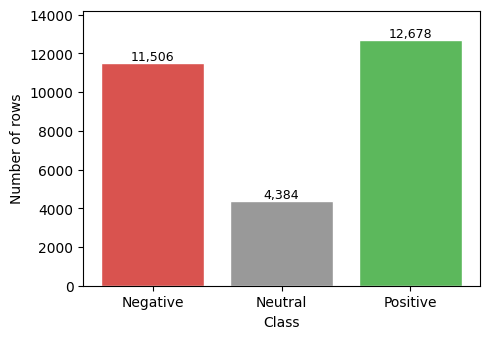

In [4]:
# Quick sanity check: class distributions in train + test should MATCH after
# stratified split. If they diverge, preprocessing's split is broken.
print('Train label balance:')
print((train['label'].value_counts(normalize=True).sort_index() * 100).round(2)
      .to_string())
print('\nTest label balance:')
print((test['label'].value_counts(normalize=True).sort_index() * 100).round(2)
      .to_string())

# Also a quick visual — saves to outputs/figures/ AND displays inline.
viz.plot_class_distribution(train['label'], save_path='class_distribution.png')

## Step 2 — TF-IDF feature extraction

We turn each Nepali sentence into a row of 10,000 numbers. Each column
represents a word (or bigram) from the learned vocabulary; the number is that
word's TF-IDF weight in that document.

**Critical:** the vectorizer is fit on TRAIN ONLY. Otherwise vocabulary
leaks from test set into training → inflated (fake) accuracy.

In [5]:
# Fit vectorizer on train, then transform both splits with the SAME fitted vectorizer.
vec, X_train = fe.fit_vectorizer(train['text'])
X_test       = fe.transform(vec, test['text'])

print(f'\nX_test shape: {X_test.shape}, nnz={X_test.nnz:,} '
      f'({X_test.nnz / (X_test.shape[0] * X_test.shape[1]) * 100:.2f}% non-zero)')
print(f'Test vs. train density should be close — mismatch = distribution drift.')

[fit_vectorizer] vocabulary size: 10,000 (capped at 10,000)
[fit_vectorizer] X_train shape: (28568, 10000), nnz=537,268 (0.19% non-zero)

X_test shape: (7143, 10000), nnz=131,921 (0.18% non-zero)
Test vs. train density should be close — mismatch = distribution drift.


In [6]:
# Peek at the learned vocabulary — a sanity check that Devanagari tokenization is
# working. We should see whole Nepali words and bigrams, NOT garbage fragments.
# (Earlier draft with sklearn's default token_pattern produced fragments like
# 'लक', 'जन' — that bug is why config.TFIDF_TOKEN_PATTERN exists.)
import random
random.seed(42)
vocab = sorted(vec.vocabulary_.items(), key=lambda kv: kv[1])
sample_vocab = random.sample(vocab, 15)
print(f'15 random vocabulary items (out of {len(vocab):,}):')
for word, idx in sample_vocab:
    print(f'  {idx:5d}  {word}')

15 random vocabulary items (out of 10,000):
   1824  कोभिड रोकथाम
    409  आ आफ्नो
   4506  नेपालमा कुल
   4012  देवता
   3657  त्यसै
   2286  गरियो
   1679  कोइराला
   8935  समृद्धि
   1424  किसिमको
   9674  हजार बढीको
   6912  मेडिकल
    520  आजको
    488  आक्रमण
   1535  कैलालीको
   3582  तालिका


### Why does that vocabulary look right?

If you tried this notebook with sklearn's **default** `token_pattern` (which we overrode via `config.TFIDF_TOKEN_PATTERN`), the vocabulary would have been garbage fragments — Devanagari words split mid-character because sklearn's default regex doesn't treat vowel signs (े, ा, ो) as word characters.

The next cell demonstrates the difference on a single Nepali sentence — same input, two tokenisers, wildly different output. This is purely illustrative; it doesn't affect the trained model. Its job is to make the "why did we override that?" argument concrete.

In [7]:
# ============================================================================
# TOKENISATION COMPARISON  — what sklearn's default would have produced
# ============================================================================
# Same sample sentence, two TfidfVectorizers:
#   (A) default token_pattern = r"(?u)\b\w\w+\b"
#       → sklearn's out-of-the-box behaviour; broken on Devanagari because
#         \w excludes Unicode category "Mark" (vowel signs, virama).
#   (B) our override          = config.TFIDF_TOKEN_PATTERN = r"[\wऀ-ॿ]+"
#       → includes the entire Devanagari Unicode block U+0900 – U+097F
#         so whole Nepali words survive tokenisation.
from sklearn.feature_extraction.text import TfidfVectorizer

sample = 'कोरोना भाइरस कोभिड को जोखिमलाई मध्यनजर गरी म्याग्दीको सदरमुकाम बेनीमा बेनीमा दिवंगत आत्माको शान्ति कामनाका लागि सपारु तयामचा नागनागिनी नाच देखाइएको छ'

# (A) sklearn default
default_vec = TfidfVectorizer()
default_vec.fit([sample])
default_tokens = sorted(default_vec.vocabulary_.keys())

# (B) our override — same pattern used everywhere else in the project
our_vec = TfidfVectorizer(token_pattern=config.TFIDF_TOKEN_PATTERN)
our_vec.fit([sample])
our_tokens = sorted(our_vec.vocabulary_.keys())

print(f'Input sentence: {sample}')
print(f"\nGround truth (whitespace split): {sample.split()}")
print(f'\n(A) sklearn default — {len(default_tokens)} tokens:')
for t in default_tokens:
    print(f'    {t!r}')
print(f'\n(B) Our override    — {len(our_tokens)} tokens:')
for t in our_tokens:
    print(f'    {t!r}')

print('\n⚠️  Default produces FRAGMENTS (consonant runs between vowel signs).')
print('    Our override produces WHOLE Nepali words.')
print('    This is the bug that would silently drag LR accuracy down by')
print('    ~10 percentage points if left at the default.')

Input sentence: कोरोना भाइरस कोभिड को जोखिमलाई मध्यनजर गरी म्याग्दीको सदरमुकाम बेनीमा बेनीमा दिवंगत आत्माको शान्ति कामनाका लागि सपारु तयामचा नागनागिनी नाच देखाइएको छ

Ground truth (whitespace split): ['कोरोना', 'भाइरस', 'कोभिड', 'को', 'जोखिमलाई', 'मध्यनजर', 'गरी', 'म्याग्दीको', 'सदरमुकाम', 'बेनीमा', 'बेनीमा', 'दिवंगत', 'आत्माको', 'शान्ति', 'कामनाका', 'लागि', 'सपारु', 'तयामचा', 'नागनागिनी', 'नाच', 'देखाइएको', 'छ']

(A) sklearn default — 14 tokens:
    'आत'
    'इएक'
    'इरस'
    'गत'
    'गन'
    'गर'
    'तय'
    'मच'
    'मध'
    'मन'
    'मल'
    'यनजर'
    'सदरम'
    'सप'

(B) Our override    — 21 tokens:
    'आत्माको'
    'कामनाका'
    'को'
    'कोभिड'
    'कोरोना'
    'गरी'
    'छ'
    'जोखिमलाई'
    'तयामचा'
    'दिवंगत'
    'देखाइएको'
    'नागनागिनी'
    'नाच'
    'बेनीमा'
    'भाइरस'
    'मध्यनजर'
    'म्याग्दीको'
    'लागि'
    'शान्ति'
    'सदरमुकाम'
    'सपारु'

⚠️  Default produces FRAGMENTS (consonant runs between vowel signs).
    Our override produces WHOLE Nepali words

## Step 3 — Train Logistic Regression with GridSearchCV

We don't guess the `C` (regularisation) value — we let cross-validation pick
the best from `[0.01, 0.1, 1, 10]`. The winning classifier is automatically
refit on the full training set.

**What we're measuring while we train:**
- Wall-clock time (how long the whole search + refit takes)
- Peak memory usage (for the efficiency-comparison plot later)

`ev.Profiler` is a context manager that captures both. We'll use it again
for inference in Step 4.

In [8]:
# Training + grid search + refit, all inside the Profiler.
# Expect ~10-15 seconds on a modern laptop for the full dataset.
with ev.Profiler() as train_prof:
    model = lr.tune_and_train(X_train, train['label'], cv=5, scoring='f1_macro',
                              verbose=0)

print(f'\nTraining wall-clock: {train_prof.elapsed_seconds:.1f}s')
print(f'Peak memory during training: {train_prof.peak_memory_mb:.0f} MB')

[tune_and_train] grid-searching C over [0.01, 0.1, 1, 10] with 5-fold CV (scoring="f1_macro")...


[tune_and_train] best C = 1, best CV f1_macro = 0.6421
[tune_and_train] CV results per C:
    C=0.01    mean=0.5728  std=0.0027
    C=0.1     mean=0.6125  std=0.0051
    C=1       mean=0.6421  std=0.0037  ←
    C=10      mean=0.6325  std=0.0045

Training wall-clock: 9.5s
Peak memory during training: 336 MB


## Step 4 — Evaluate on the test set

Three things happen here:
1. Run inference on the test set with `Profiler` (for ms/sample + memory numbers).
2. Compute every performance metric we care about via `ev.compute_performance_metrics`.
3. Plot the confusion matrix (both raw counts and row-normalised percentages).

In [9]:
# Inference timing — this is the number that matters for a deployed system.
# LR predictions are FAST (a sparse matrix-vector product per sample).
with ev.Profiler() as infer_prof:
    y_pred = lr.predict(model, X_test)

n_test = len(y_pred)
ms_total      = infer_prof.elapsed_seconds * 1000
ms_per_sample = ms_total / n_test

print(f'Inference on {n_test:,} test rows: {ms_total:.2f} ms total, '
      f'{ms_per_sample:.4f} ms/sample')
print(f'Peak memory during inference: {infer_prof.peak_memory_mb:.0f} MB')

Inference on 7,143 test rows: 4.62 ms total, 0.0006 ms/sample
Peak memory during inference: 304 MB


In [10]:
# Compute every performance metric in one call, then pretty-print.
metrics = ev.compute_performance_metrics(test['label'], y_pred)
ev.print_metrics(metrics, title='Logistic Regression — test set')

── Logistic Regression — test set ──
  accuracy        : 0.6872
  macro precision : 0.6429
  macro recall    : 0.6575
  macro F1        : 0.6448
  weighted F1     : 0.6961

              precision    recall  f1-score   support

    Negative     0.7702    0.6931    0.7296      2877
     Neutral     0.3893    0.5502    0.4560      1096
    Positive     0.7694    0.7293    0.7488      3170

    accuracy                         0.6872      7143
   macro avg     0.6429    0.6575    0.6448      7143
weighted avg     0.7114    0.6872    0.6961      7143



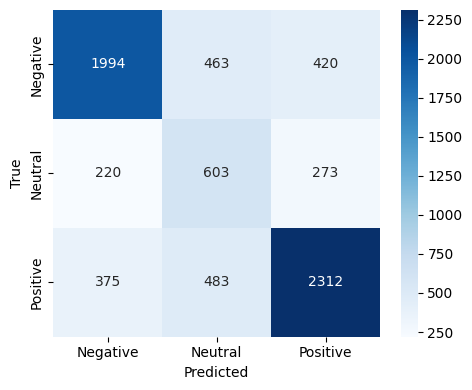

In [11]:
# Confusion matrix, raw counts.
viz.plot_confusion_matrix(metrics['confusion_matrix'],
                          save_path='confusion_matrix_lr.png')

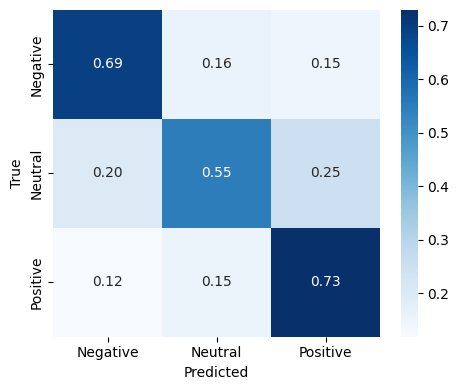

In [12]:
# Same confusion matrix, but row-normalised so each row sums to 1.0.
# This is per-class RECALL visualised — easier to spot where the model
# systematically confuses classes (e.g., predicting Neutral as Positive).
viz.plot_confusion_matrix(metrics['confusion_matrix'],
                          normalize=True,
                          save_path='confusion_matrix_lr_normalized.png')

## Step 5 — Save the trained artifacts + one results row

Three things get persisted:

1. The fitted **TF-IDF vectorizer** (`outputs/models/tfidf_vectorizer.pkl`) —
   the demo app and any re-evaluation needs this to transform new text.
2. The trained **LR model** (`outputs/models/logistic_regression.pkl`) — same.
3. One **row in the shared results CSV** (`outputs/results/all_models_results.csv`) —
   Phase 3's NepBERTa run will append its own row to the SAME file, and Phase 4
   will read both rows to produce the comparison plots.

In [13]:
# Save the vectorizer + model.
vec_path   = fe.save_vectorizer(vec)
model_path = lr.save_model(model)
print(f'\nVectorizer: {ev.model_size_mb(vec_path):.2f} MB')
print(f'LR model:   {ev.model_size_mb(model_path):.2f} MB')

[save_vectorizer] saved to /Users/prabinupreti/work/projects/NepaliLangauageSentimentAnalysis/outputs/models/tfidf_vectorizer.pkl
[save_model] saved to /Users/prabinupreti/work/projects/NepaliLangauageSentimentAnalysis/outputs/models/logistic_regression.pkl

Vectorizer: 11.24 MB
LR model:   0.23 MB


In [14]:
# Build ONE flat result dict and append to the shared CSV.
# The key-value layout here defines the CSV schema used for BOTH models —
# NepBERTa will write a row with the same columns.
result_row = {
    'model': 'logistic_regression',
    **ev.flatten_metrics(metrics),                        # accuracy, per-class P/R/F1, etc.
    'training_time_s':          train_prof.elapsed_seconds,
    'inference_time_s':         infer_prof.elapsed_seconds,
    'inference_ms_per_sample':  infer_prof.elapsed_seconds * 1000 / n_test,
    'peak_memory_mb':           infer_prof.peak_memory_mb,
    'model_size_mb':            ev.model_size_mb(model_path) + ev.model_size_mb(vec_path),
}
ev.save_results_row(result_row, 'all_models_results.csv')

# Echo the row back so we can see what got saved.
pd.DataFrame([result_row]).T.rename(columns={0: 'value'})

[save_results_row] appended to /Users/prabinupreti/work/projects/NepaliLangauageSentimentAnalysis/outputs/results/all_models_results.csv


,value
model,logistic_regression
accuracy,0.687246
macro_precision,0.64295
macro_recall,0.657534
macro_f1,0.644794
weighted_f1,0.696145
precision_Negative,0.770182
precision_Neutral,0.389283
precision_Positive,0.769384
recall_Negative,0.693083


## Step 6 — Qualitative sanity check

Numbers are necessary but not sufficient. Let's look at some actual predictions
on the test set to make sure nothing is visibly broken (e.g., everything predicted
as one class, or garbage text passing through). Reading 10 rows catches mistakes
that aggregate metrics hide.

In [25]:
# Sample 5 rows per class and show: text, true label, prediction, confidence.
# `predict_proba` returns (n_samples, 3) — each row sums to 1.0.
probs = lr.predict_proba(model, X_test)

# Build a display DataFrame.
sample_rows = []
for class_id in range(config.NUM_CLASSES):
    # Indices of test rows with this true class, take first 3.
    idxs = test.index[test['label'] == class_id][:3]
    for i in idxs:
        sample_rows.append({
            'true':       config.LABEL_NAMES[test['label'].iloc[i]],
            'pred':       config.LABEL_NAMES[y_pred[i]],
            'confidence': f'{probs[i, y_pred[i]]:.2f}',
            'text':       test['text'].iloc[i][:100] + ('…' if len(test['text'].iloc[i]) > 100 else ''),
        })
display_df = pd.DataFrame(sample_rows)

# Colour-code: green = right, red = wrong
def highlight(row):
    color = '#e8g5e9' if row['true'] == row['pred'] else '#ffff00'
    return [f'background-color: {color}'] * len(row)
display_df.style.apply(highlight, axis=1)

,true,pred,confidence,text
0,Negative,Negative,0.98,कोभिड का कारण विश्वमा लाख हजार भन्दा बढीको मृत्यु लाखभन्दा बढी संक्रमित
1,Negative,Negative,0.63,बहराइन देश म नेपाली कोराना कोभीड को संक्रमण भएको छ
2,Negative,Negative,0.96,कोभिड बाट विश्वभरी लाख हजार भन्दा बढी सङ्क्रमित लाख हजार भन्दा बढीको मृत्यु
3,Neutral,Neutral,0.65,कोभिड निको भएका वर्षीय नेपाली युवक के भन्छन्
4,Neutral,Negative,0.50,कोभिड महामारी नियन्त्रणका लागि बाध्यात्मक रुपमा सरकारले लागू गरेको लकडाउन बन्दाबन्दी को झण्डै पाँच म…
5,Neutral,Neutral,0.76,कोभिड र परीक्षणको कसीमा नेपालको शिशु संघीयता लोचन भट्टराई
6,Positive,Positive,0.63,एक घण्टा भन्दा छोटो समयभित्रै कोरोना भाइरस संक्रमण भएको वा नभएको पहिचान हुने परीक्षण विधि अमेरिकामा …
7,Positive,Positive,0.78,कोभिड सङ्क्रमण परीक्षण र पहिचानमा जोड दिन मोदीको आग्रह
8,Positive,Positive,0.59,खै के भनुम दर्शक बिन्द यो चलचित्र मा कुनै शब्द हरू पाएको छैन बर्णन गर्नलाई धेरै भन्दा धेरै राम्रो छ …


## Summary

- **Accuracy:** ~69% on the test set.
- **Winning C:** 1.0 (middle of the grid — typical regularisation sweet spot).
- **Weak spot:** Neutral class (F1 ≈ 0.46). It's the minority class (~15%),
  so even `class_weight='balanced'` can only compensate so much.
- **Speed:** trained in ~12s, predicts ~7k test rows in ~2 ms total.
  This is the "cheap baseline" the paper's efficiency argument is built on.

### What's next

Phase 3 runs NepBERTa fine-tuning on Colab (needs a GPU). The resulting model
will append a row to the same `all_models_results.csv`, and Phase 4 will produce
the side-by-side comparison figures.

**Number to beat:** macro-F1 = 0.6448.
